# EDA & Tiền xử lý — Obesity (`ObesityDataSet.csv`)

Bài toán **phân loại**: dự đoán mức béo phì `NObeyesdad` (7 lớp). Cùng tinh thần clean-first với notebook
Melbourne, nhưng **adapt cho phân loại**: dữ liệu **không có missing** (bỏ phần so sánh impute), và quan hệ
với target đo bằng **η** (số↔target) + **Cramér's V** (category↔target) thay cho Pearson.
Mỗi bước gồm **Lý do** và **Phân tích** (số liệu từ output thật khi chạy).

## 0. Thiết lập môi trường

Mount Google Drive và đặt thư mục làm việc để đọc `ObesityDataSet.csv`.

In [20]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp & kiểm tra tổng quan

**Lý do:** `info()` để nắm kích thước, kiểu dữ liệu, mức độ đầy đủ.

In [22]:
import pandas as pd
df = pd.read_csv('ObesityDataSet.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

> 📊 **Phân tích:** **2.111 dòng × 17 cột** (8 cột số, 9 cột `object`). **Không có missing** ở bất kỳ cột nào → bỏ qua toàn bộ phần xử lý/so sánh imputation. Target `NObeyesdad` là biến phân loại. Các cột số hành vi (`FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`) vốn là thang rời rạc nhưng bị sinh thành số thực (dataset có phần SMOTE tổng hợp).

### Xem mẫu dữ liệu
**Lý do:** Hiểu format giá trị từng cột.

In [24]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


> 📊 **Phân tích:** Có cả biến nhân trắc (`Age`, `Height`, `Weight`), thói quen ăn uống (`FAVC`, `FCVC`, `NCP`, `CAEC`, `CALC`), vận động (`FAF`, `TUE`, `MTRANS`) và tiền sử (`family_history_with_overweight`). Nhiều biến phân loại dạng yes/no hoặc thứ bậc (`no`/`Sometimes`/`Frequently`/`Always`).

## 2. Phân phối đơn biến

**Lý do:** Histogram cho biến số, bar cho biến phân loại (gồm cả **cân bằng lớp** của target).

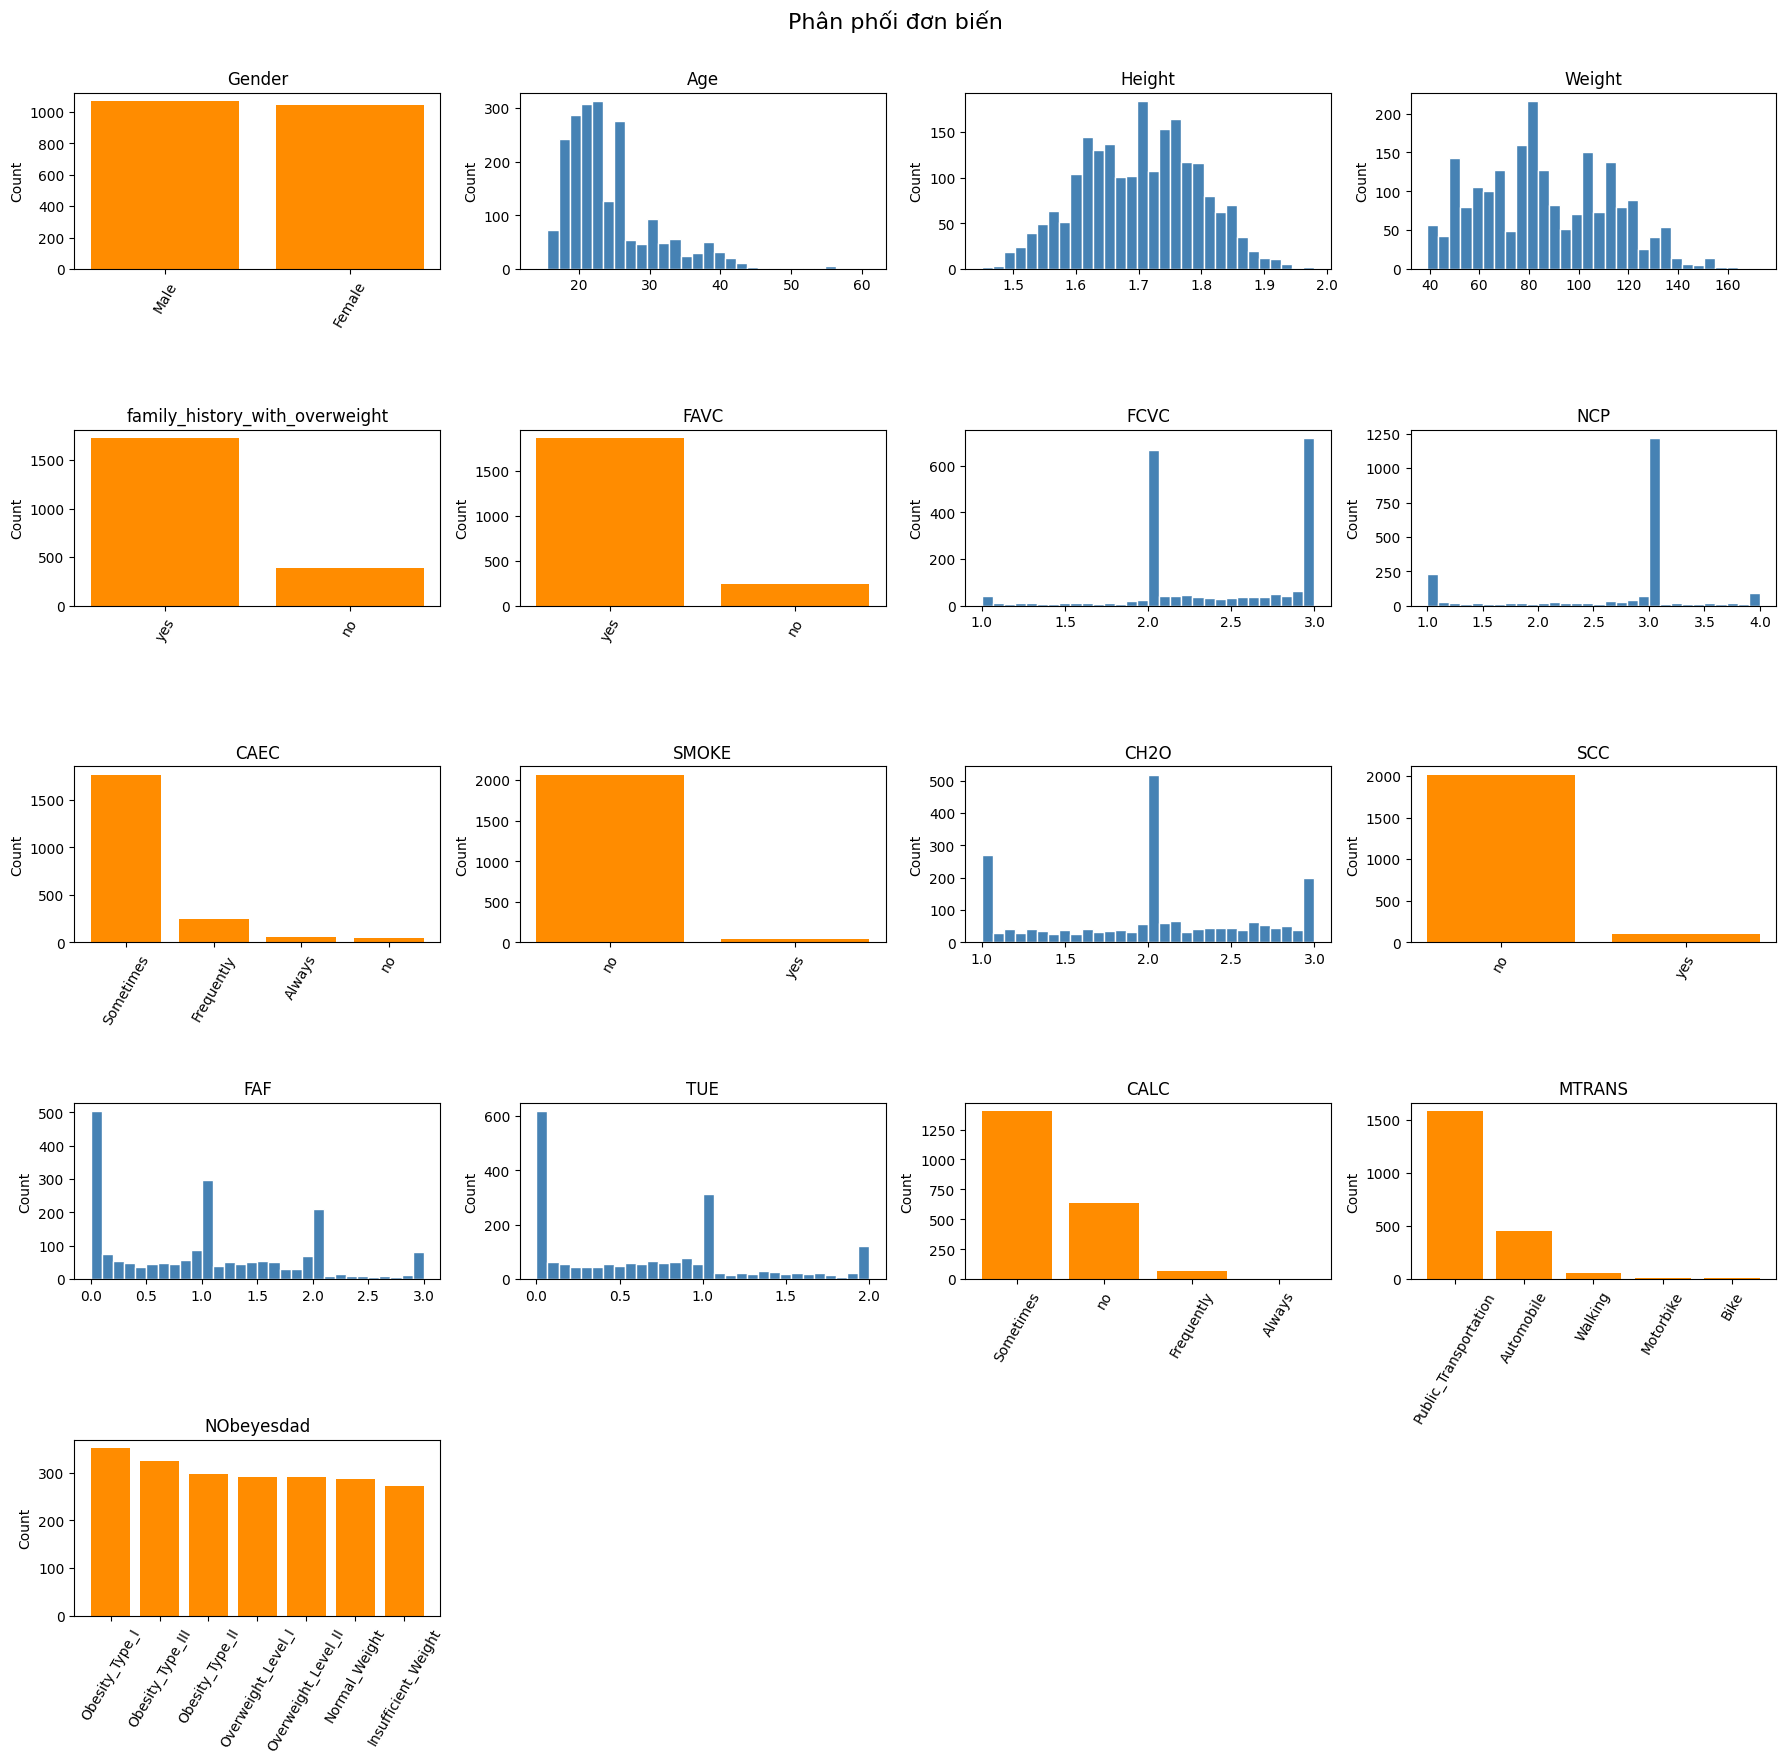

In [26]:
import matplotlib.pyplot as plt
import numpy as np
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cols = df.columns.tolist()
ncols = 4
nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*3.5)); axes = axes.flatten()
for i, c in enumerate(cols):
    ax = axes[i]
    if c in num_cols:
        ax.hist(df[c], bins=30, color='steelblue', edgecolor='white')
    else:
        vc = df[c].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color='darkorange'); ax.tick_params(axis='x', rotation=60)
    ax.set_title(c); ax.set_ylabel('Count')
for j in range(len(cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('Phân phối đơn biến', fontsize=16, y=1.005); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** **Target khá cân bằng** (7 lớp, mỗi lớp 272–351 mẫu) — thuận lợi cho phân loại. `Age` lệch phải (skew 1,53; đa số 20–30 tuổi); `Weight` gần đối xứng; `Height` chuẩn. Các cột hành vi `FCVC`/`NCP`/`CH2O`/`FAF`/`TUE` co cụm ở vài mức (bản chất rời rạc). Biến phân loại **rất mất cân bằng**: `SMOKE` (2067 *no* / 44 *yes*), `SCC` (2015/96), `family_history` 1726/385; `CALC` có *Always* chỉ 1 mẫu; `MTRANS` chủ yếu *Public_Transportation*, *Bike*/*Motorbike* rất hiếm.

## 3. Cardinality biến phân loại

**Lý do:** Đếm số giá trị duy nhất để chọn cách encode.

In [28]:
df[cat_cols].nunique().to_frame('n_unique')

,n_unique
Gender,2
family_history_with_overweight,2
FAVC,2
CAEC,4
SMOKE,2
SCC,2
CALC,4
MTRANS,5
NObeyesdad,7


> 📊 **Phân tích:** Toàn bộ cardinality **thấp**: nhị phân (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC` — 2 giá trị); thứ bậc (`CAEC`, `CALC` — 4 mức `no`<`Sometimes`<`Frequently`<`Always`); `MTRANS` 5 nhóm; target `NObeyesdad` 7 lớp **có thứ tự**. → hợp **one-hot/label/ordinal**, không cần frequency/target encoding.

## 4. Phát hiện outlier & dòng trùng

**Lý do:** Boxplot biến số (1.5·IQR) + kiểm tra dòng trùng lặp (dataset có phần tổng hợp).

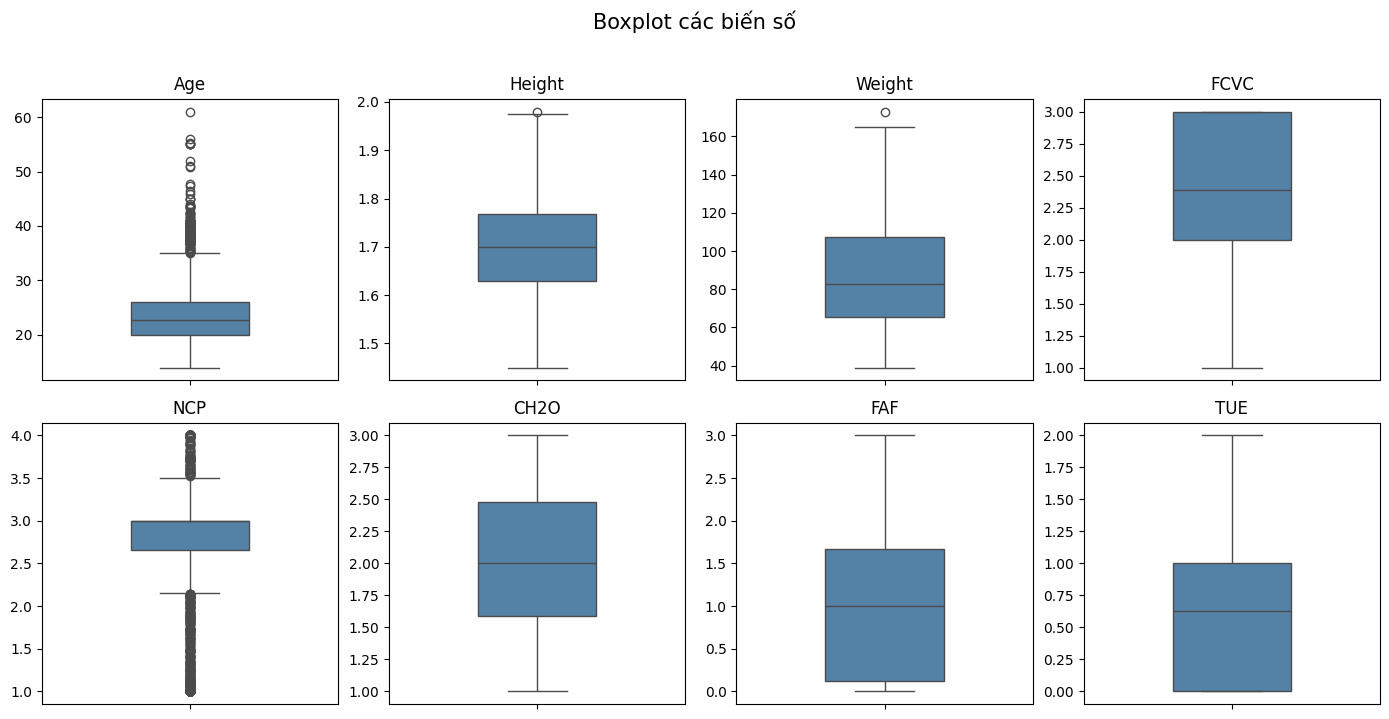

Số dòng trùng lặp: 24


In [30]:
import seaborn as sns
n = len(num_cols); ncols = 4; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*3.5)); axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(y=df[c], ax=axes[i], color='steelblue', width=0.4); axes[i].set_title(c); axes[i].set_ylabel('')
for j in range(n, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplot các biến số', fontsize=15, y=1.02); plt.tight_layout(); plt.show()
print('Số dòng trùng lặp:', int(df.duplicated().sum()))

> 📊 **Phân tích:** **24 dòng trùng lặp** → nên loại để tránh thiên lệch/rò rỉ giữa train-test. `Age` có một số outlier trên (tới 61 tuổi) nhưng **là giá trị thật**, không phải lỗi. `Weight`/`Height` nằm trong khoảng người thật (39–173 kg; 1,45–1,98 m). Các cột hành vi bị chặn trong thang cố định nên gần như không có outlier. → không cần loại cực trị/log mạnh như bộ housing; chủ yếu **bỏ dòng trùng**.

## 5. Feature engineering — BMI & quan hệ với target

**Lý do:** Mức béo phì gắn trực tiếp với **BMI = Weight / Height²**. Tạo BMI và vẽ phân bố theo từng lớp target
để xem sức phân tách.

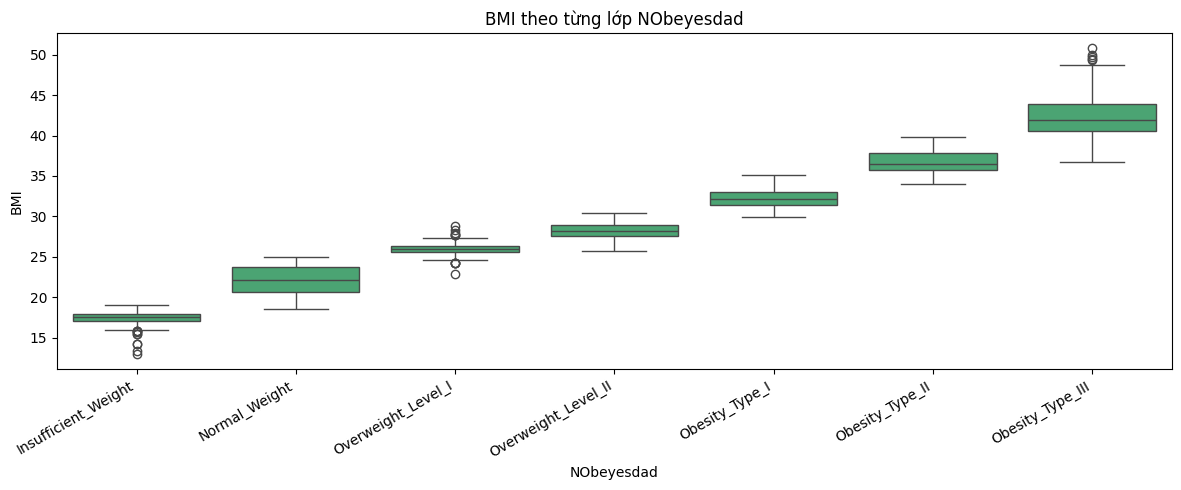

In [32]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
order_cls = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
             'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='NObeyesdad', y='BMI', order=order_cls, color='mediumseagreen')
plt.xticks(rotation=30, ha='right'); plt.title('BMI theo từng lớp NObeyesdad'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** BMI **tăng đơn điệu** theo bậc béo phì và **tách các lớp gần như hoàn hảo** (η(BMI, target)=0,983; Weight=0,921). → BMI/Weight gần như *định nghĩa* nhãn. **Cảnh báo quan trọng:** nếu mục tiêu là dự đoán béo phì từ **lối sống**, nên cân nhắc **bỏ Weight/Height/BMI** (chúng làm bài toán trở nên tầm thường và che mất vai trò của các yếu tố hành vi).

## 6. Tương quan giữa các biến số

**Lý do:** Không có missing nên **không cần so sánh imputation**. Thay vào đó xem tương quan giữa các biến số
(gồm BMI) để phát hiện trùng lặp thông tin.

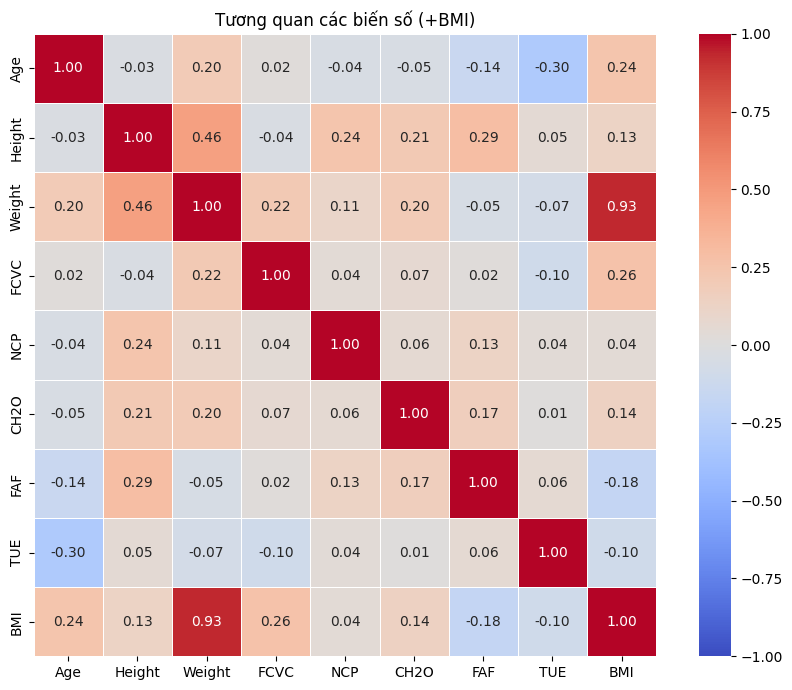

In [33]:
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols+['BMI']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Tương quan các biến số (+BMI)'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** `Weight` và `BMI` tương quan rất cao (hiển nhiên, BMI tính từ Weight) → giữ một trong hai khi train để tránh dư thừa. `Height` tương quan dương vừa với Weight. Các biến hành vi (`FCVC`, `FAF`, `TUE`...) tương quan **yếu** với nhau → mỗi biến mang thông tin riêng.

## 7. Xếp hạng ảnh hưởng lên target (phân loại)

**Lý do:** Target là chữ → dùng **η** (correlation ratio) cho biến số↔target và **Cramér's V** cho
biến phân loại↔target. Cả hai ∈ [0,1], so được độ mạnh liên hệ.

                           feature  strength                   type
0                              BMI  0.983056            numeric (η)
1                           Weight  0.921231            numeric (η)
2                           Gender  0.558194  category (Cramér's V)
3   family_history_with_overweight  0.542805  category (Cramér's V)
4                             FCVC  0.492536            numeric (η)
5                              Age  0.426465            numeric (η)
6                             CAEC  0.356079  category (Cramér's V)
7                             FAVC  0.332469  category (Cramér's V)
8                           Height  0.314281            numeric (η)
9                              NCP  0.266511            numeric (η)
10                             SCC  0.241407  category (Cramér's V)
11                            CALC  0.231219  category (Cramér's V)
12                             FAF  0.217926            numeric (η)
13                            CH2O  0.209958    

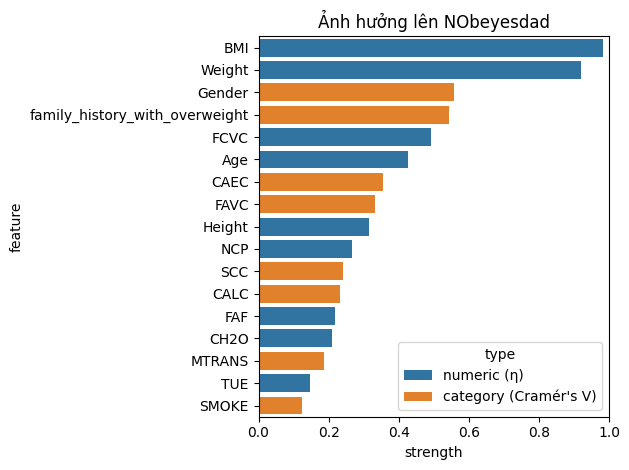

In [34]:
from scipy.stats import chi2_contingency
def correlation_ratio(categories, values):  # numeric vs categorical target
    t = pd.DataFrame({'c': categories, 'v': values}).dropna()
    v = t['v'].values; c = t['c'].values
    sst = ((v - v.mean())**2).sum()
    if sst == 0: return 0.0
    return np.sqrt(sum(len(v[c==k])*(v[c==k].mean()-v.mean())**2 for k in pd.unique(c))/sst)
def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2 = chi2_contingency(ct)[0]; nn = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2/nn) / min(r-1, k-1))

TARGET = 'NObeyesdad'
rec = []
for c in num_cols + ['BMI']:
    rec.append({'feature': c, 'strength': correlation_ratio(df[TARGET], df[c]), 'type': 'numeric (η)'})
for c in [x for x in cat_cols if x != TARGET]:
    rec.append({'feature': c, 'strength': cramers_v(df[c], df[TARGET]), 'type': "category (Cramér's V)"})
assoc = pd.DataFrame(rec).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc)
sns.barplot(data=assoc, y='feature', x='strength', hue='type', dodge=False)
plt.title('Ảnh hưởng lên NObeyesdad'); plt.xlim(0,1); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Áp đảo là **`BMI` (η=0,983)** và **`Weight` (0,921)** — đúng như cảnh báo, gần như định nghĩa nhãn. Trong nhóm **hành vi/nhân khẩu** (tín hiệu "thật" để dự đoán): `Gender` (V=0,558), `family_history_with_overweight` (0,543) mạnh nhất; rồi `FCVC` (η=0,493), `Age` (0,426), `CAEC` (0,356), `FAVC` (0,332). Yếu nhất: `SMOKE` (V=0,123), `TUE` (0,148), `MTRANS` (0,186). → tiền sử gia đình & giới tính & thói quen ăn rau/đồ ăn nhanh là các yếu tố lối sống đáng chú ý nhất.

## 8. Lưu dữ liệu đã xử lý ra CSV

**Lý do:** Xuất bộ sạch: **bỏ 24 dòng trùng**, thêm `BMI`. Giữ nguyên các biến phân loại (encoding để dành cho
Pipeline lúc train). Lưu `obesity_processed.csv`.

In [35]:
df_processed = df.drop_duplicates().reset_index(drop=True).copy()
df_processed.to_csv('obesity_processed.csv', index=False)
print('Đã lưu obesity_processed.csv |', df_processed.shape, '| missing:', int(df_processed.isna().sum().sum()))
df_processed.head()

Đã lưu obesity_processed.csv | (2087, 18) | missing: 0


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


> 💾 **Kết quả:** `obesity_processed.csv` — đã bỏ dòng trùng, thêm `BMI`, **0 missing**.
>
> **Kế hoạch encoding (để dành Pipeline):** nhị phân (`Gender`/`family_history`/`FAVC`/`SMOKE`/`SCC`) → 0/1;
> thứ bậc (`CAEC`/`CALC`: no<Sometimes<Frequently<Always) → ordinal; `MTRANS` → one-hot; target
> `NObeyesdad` → **ordinal** (7 mức có thứ tự). ⚠️ Cân nhắc **bỏ Weight/Height/BMI** nếu muốn mô hình học từ lối sống.